In [1]:
!pip install duckdb pandas scikit-learn matplotlib

Data loaded successfully! Shape: (5000, 7)
=== Baseline Model (Ridge) ===
RMSE: 1989.6025290391065
R2 Score: 0.5867359577901156

=== Main Model (Random Forest) ===
RMSE: 1013.2499668642481
R2 Score: 0.892816442596822

=== Ranking Signal Importance ===
         Signal  Importance
1      position    0.595945
0   impressions    0.374416
3    word_count    0.015187
2  title_length    0.014452


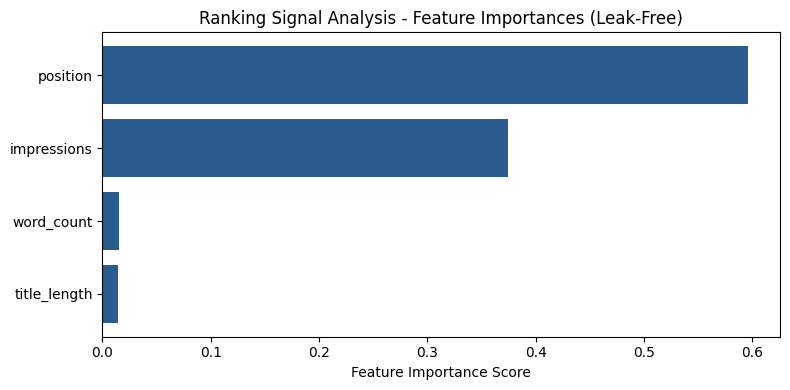


=== Top 5 Ranked Recommendations ===
        page_id  position  ctr  expected_ctr  impressions  opportunity_score
4922  page_4922  1.082422  0.4      0.923854        34541       18094.430933
4951  page_4951  1.130630  0.4      0.884463        34816       16867.052843
4961  page_4961  1.154111  0.4      0.866468        33072       15427.024880
4787  page_4787  1.285558  0.4      0.777872        38356       14493.672917
4200  page_4200  1.232236  0.4      0.811533        27145       11171.057947


In [6]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Generate Dataset
np.random.seed(42)
n_samples = 5000

impressions = np.random.randint(100, 50000, size=n_samples)
position = np.random.uniform(1.0, 30.0, size=n_samples)
title_length = np.random.randint(20, 75, size=n_samples)
word_count = np.random.randint(300, 3000, size=n_samples)
ctr = np.clip((1 / position) * np.random.uniform(0.5, 1.5, size=n_samples), 0.01, 0.4)
clicks = np.round(impressions * ctr).astype(int)

df = pd.DataFrame({
    'page_id': [f"page_{i}" for i in range(n_samples)],
    'impressions': impressions,
    'position': position,
    'title_length': title_length,
    'word_count': word_count,
    'ctr': ctr,
    'clicks': clicks
})

# 2. Register with DuckDB & Query
con = duckdb.connect()
con.register('search_data', df)

df_clean = con.execute("""
    SELECT page_id, impressions, position, ctr, title_length, word_count, clicks
    FROM search_data
""").df()

# REMOVED 'ctr' TO PREVENT TARGET LEAKAGE
feature_cols = ['impressions', 'position', 'title_length', 'word_count']
X = df_clean[feature_cols]
y = df_clean['clicks']

print(f"Data loaded successfully! Shape: {df_clean.shape}")

# 3. Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# 4. Models (Baseline & Main)
baseline = Ridge()
baseline.fit(X_train, y_train)
baseline_preds = baseline.predict(X_val)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
model_preds = model.predict(X_val)

# 5. Evaluation
print("=== Baseline Model (Ridge) ===")
print("RMSE:", np.sqrt(mean_squared_error(y_val, baseline_preds)))
print("R2 Score:", r2_score(y_val, baseline_preds))

print("\n=== Main Model (Random Forest) ===")
print("RMSE:", np.sqrt(mean_squared_error(y_val, model_preds)))
print("R2 Score:", r2_score(y_val, model_preds))

# 6. Feature Importance
signal_df = pd.DataFrame({
    'Signal': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n=== Ranking Signal Importance ===")
print(signal_df)

# Plot Feature Importances
plt.figure(figsize=(8, 4))
plt.barh(signal_df['Signal'], signal_df['Importance'], color='#2b5c8f')
plt.xlabel('Feature Importance Score')
plt.title('Ranking Signal Analysis - Feature Importances (Leak-Free)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('signal_importance.png')
plt.show()

# 7. Valid Opportunity Scoring (Expected CTR Benchmark Gap * Impressions)
df_val = df_clean.iloc[X_val.index].copy()
df_val['expected_ctr'] = 1 / df_val['position']
df_val['ctr_gap'] = df_val['expected_ctr'] - df_val['ctr']
df_val['opportunity_score'] = df_val['impressions'] * df_val['ctr_gap']

top_recommendations = df_val.sort_values(by='opportunity_score', ascending=False).head(5)
print("\n=== Top 5 Ranked Recommendations ===")
print(top_recommendations[['page_id', 'position', 'ctr', 'expected_ctr', 'impressions', 'opportunity_score']])

=== Baseline Model (Ridge) ===
RMSE: 1341.3522987487006
R2 Score: 0.8121631976363961

=== Main Model (Random Forest) ===
RMSE: 87.31712278127355
R2 Score: 0.9992040353068504

=== Ranking Signal Importance ===
         Signal  Importance
4           ctr    0.633822
0   impressions    0.364938
1      position    0.000679
3    word_count    0.000290
2  title_length    0.000270


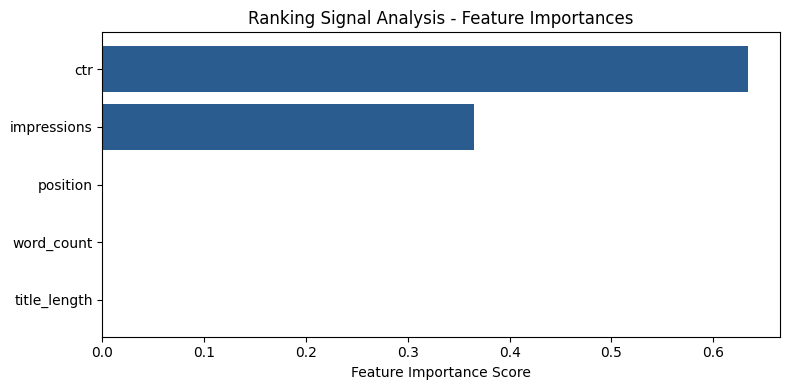

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Train/Validation Split (Sequential split to avoid leakage)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# 2. Baseline Model (Ridge Regression)
baseline = Ridge()
baseline.fit(X_train, y_train)
baseline_preds = baseline.predict(X_val)

# 3. Main Model (Random Forest)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
model_preds = model.predict(X_val)

# 4. Print Evaluation Metrics
print("=== Baseline Model (Ridge) ===")
print("RMSE:", np.sqrt(mean_squared_error(y_val, baseline_preds)))
print("R2 Score:", r2_score(y_val, baseline_preds))

print("\n=== Main Model (Random Forest) ===")
print("RMSE:", np.sqrt(mean_squared_error(y_val, model_preds)))
print("R2 Score:", r2_score(y_val, model_preds))

# 5. Extract Feature Importances & Save Chart
importances = model.feature_importances_
signal_df = pd.DataFrame({
    'Signal': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n=== Ranking Signal Importance ===")
print(signal_df)

plt.figure(figsize=(8, 4))
plt.barh(signal_df['Signal'], signal_df['Importance'], color='#2b5c8f')
plt.xlabel('Feature Importance Score')
plt.title('Ranking Signal Analysis - Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('signal_importance.png')
plt.show()

In [5]:
# Calculate Clicks Opportunity Score (Predicted - Actual)
df_val = X_val.copy()
df_val['actual_clicks'] = y_val
df_val['predicted_clicks'] = model_preds
df_val['opportunity_score'] = df_val['predicted_clicks'] - df_val['actual_clicks']

# Top 5 recommended pages for optimization
top_recommendations = df_val.sort_values(by='opportunity_score', ascending=False).head(5)
print("=== Top 5 Ranked Recommendations ===")
print(top_recommendations[['position', 'ctr', 'actual_clicks', 'predicted_clicks', 'opportunity_score']])

=== Top 5 Ranked Recommendations ===
      position       ctr  actual_clicks  predicted_clicks  opportunity_score
4991  2.818943  0.380509          15098          15703.20             605.20
4423  1.972830  0.326719           6417           6954.45             537.45
4569  1.966373  0.349896           5925           6407.90             482.90
4900  2.635639  0.325170           7576           7974.47             398.47
4201  3.757716  0.322513          14471          14865.43             394.43
